# FRACTAL ROLLING HURST REGIME DETECTION PIPELINE

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime, timedelta
import yfinance as yf
# display and store Matplotlib plots within a Python Jupyter notebook
%matplotlib inline

In [4]:
from scipy.linalg import cholesky
from scipy import stats
from scipy.stats import norm, linregress

In [5]:
from sklearn.preprocessing import  MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans

In [6]:
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, silhouette_score, calinski_harabasz_score, davies_bouldin_score
)

In [7]:
import platform
print(f"Python version: {platform.python_version()}")
print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
import matplotlib
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"yfinance version: {yf.__version__}")
import sklearn
print(f"sklearn version: {sklearn.__version__}")
#print(f"Pytorch version: {torch.__version__}")
import scipy
print(f"scipy version: {scipy.__version__}")

Python version: 3.10.14
Numpy version: 1.26.4
Pandas version: 2.1.4
Matplotlib version: 3.7.5
Seaborn version: 0.13.2
yfinance version: 1.4.1
sklearn version: 1.6.1
scipy version: 1.11.4


Loading S&P 500 data...
N = 6658 returns | 2000-01-04 to 2026-06-25
Prices: 6659 points | Dates: 6659 points

Fitting FractalRegimeClassifier with auto K-detection...


Descriptive statistics
            H_rs  D_higuchi     d_frac  alpha_dfa  volatility
count  98.000000  98.000000  98.000000  98.000000   98.000000
mean    0.575881   1.043562   0.075881   0.480429   18.127336
std     0.044773   0.047080   0.044773   0.060783    6.679187
min     0.454943   0.942283  -0.045057   0.306971    9.971126
25%     0.554953   1.014477   0.054953   0.447810   13.097684
50%     0.574878   1.039713   0.074878   0.479101   16.339479
75%     0.603079   1.070281   0.103079   0.519547   21.706131
max     0.671877   1.227613   0.171877   0.679244   35.250376


AUTO-DETECTING OPTIMAL K (Elbow + Silhouette)
  K      Inertia   Silhouette     Calinski Davies-Bouldin
  2       345.06       0.2494        40.32         1.3803
  3       278.02       0.2255        36.22         1.3713
  4       216.16       0.277

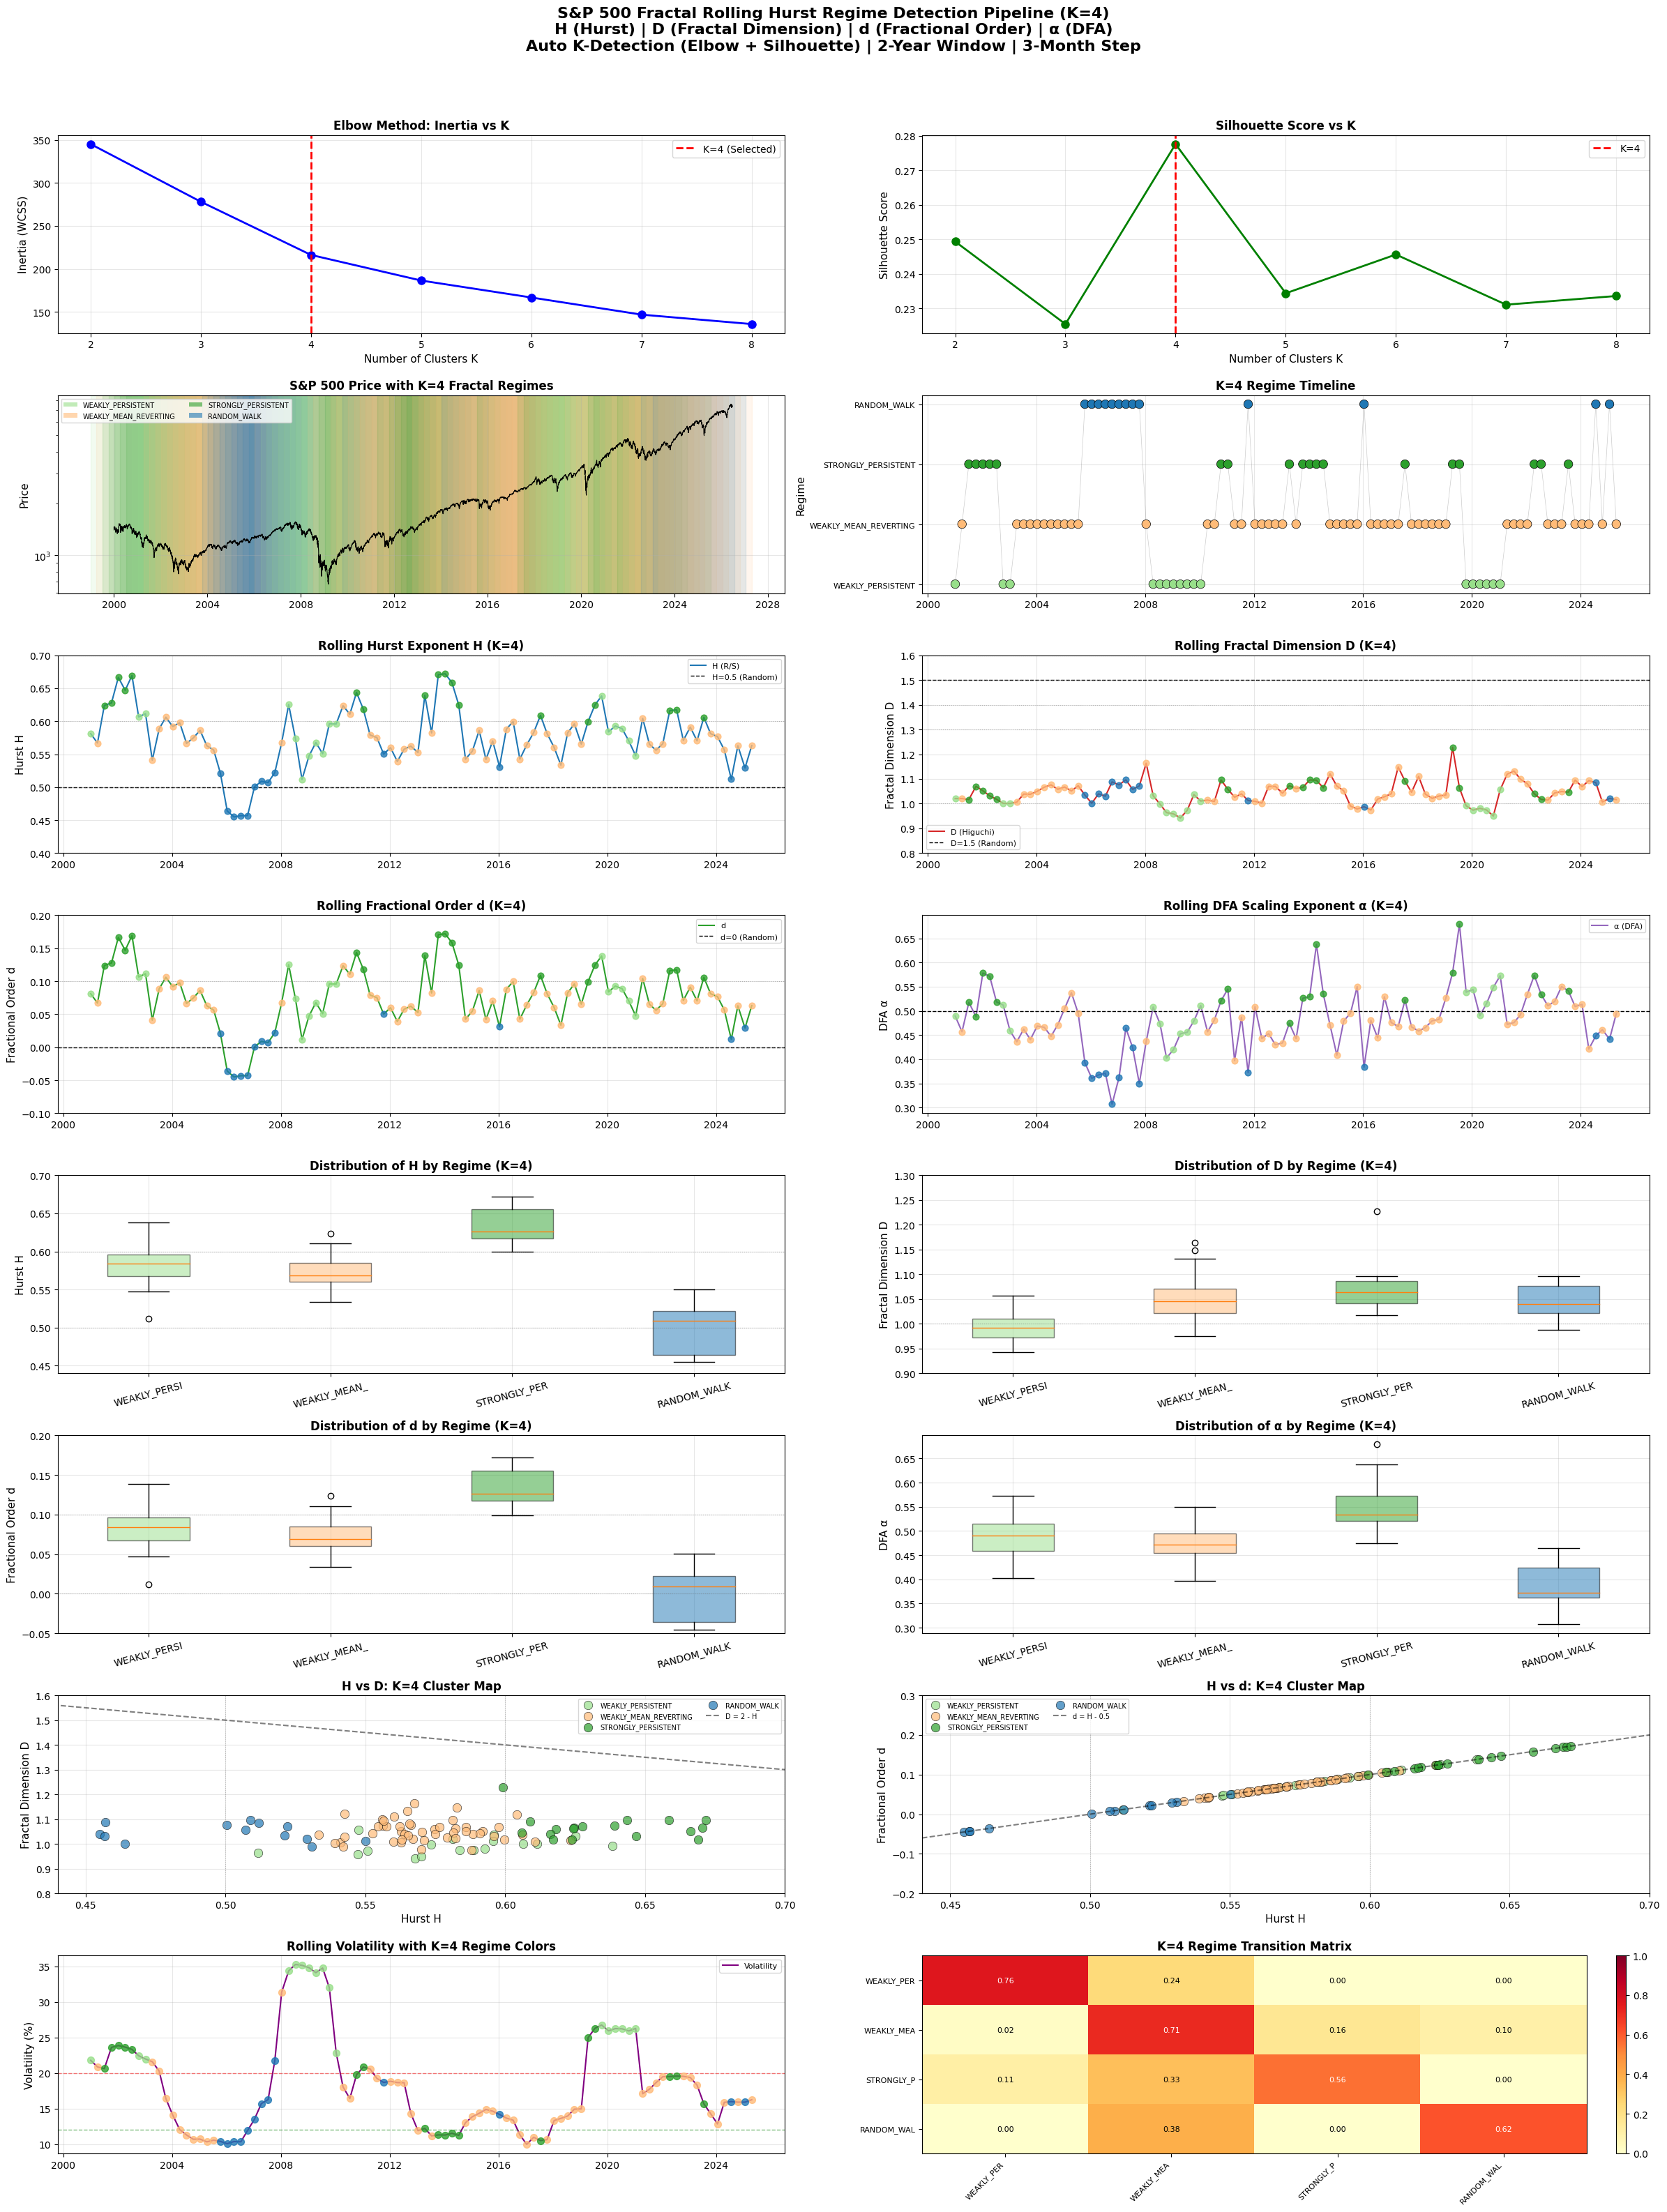


Done! Saved to: fractal_regime_dashboard_autok.png


In [8]:
"""
================================================================================
FRACTAL ROLLING HURST REGIME DETECTION PIPELINE
================================================================================
With K-Means Clustering (Elbow + Silhouette Auto-Detection), Full 16-Panel Dashboard,
Distributions, Transition Matrix, and Reusable FractalRegimeClassifier

Metrics: H (Hurst), D (Fractal Dimension), d (Fractional Order), α (DFA)
Data: S&P 500 Index (^GSPC) from 2000-01-01 to 2026-06-26

8 Canonical Regimes based on H, D=2-H, d=H-0.5:
| H       | D = 2−H | d = H−0.5 | Regime                              | Roughness         |
| ------- | ------- | --------- | ----------------------------------- | ----------------- |
| 1.0     | 1.0     | +0.5      | Perfect trend                       | Smooth            |
| 0.7     | 1.3     | +0.2      | Strongly persistent / trending      | Moderately smooth |
| 0.6     | 1.4     | +0.1      | Weakly persistent                   | Slightly smooth   |
| 0.5     | 1.5     | 0         | Random walk                         | Neutral           |
| 0.4     | 1.6     | −0.1      | Weakly mean-reverting               | Slightly rough    |
| 0.3     | 1.7     | −0.2      | Strongly mean-reverting             | Moderately rough  |
| 0.1     | 1.9     | −0.4      | Extreme anti-persistence            | Very rough        |
| 0.0     | 2.0     | −0.5      | Perfect anti-persistence            | Maximally rough   |

NOTE ON H=0.0: This is NOT white noise (which has H=0.5, uncorrelated increments).
H=0.0 implies perfectly NEGATIVELY correlated adjacent increments — the strongest
possible anti-persistent memory. Every up-move is perfectly reversed by the next
down-move, producing maximally rough paths. This is the OPPOSITE of "no memory."

Dependencies:
    pip install pandas numpy matplotlib scipy scikit-learn yfinance

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')


# =============================================================================
# PART 1: FRACTAL ANALYSIS FUNCTIONS
# =============================================================================

def generate_scales(window_size, min_scale=16, max_ratio=0.1, num_scales=12):
    """
    Generate dense power-law scales for fractal analysis.

    Uses dyadic scaling: n = 2^k, where k is linearly spaced in log2 space.
    This ensures scales are well-distributed across orders of magnitude,
    which is critical for accurate power-law regression in R/S and DFA.

    Parameters:
    -----------
    window_size : int
        Length of the rolling analysis window (in data points).
    min_scale : int
        Minimum scale to use (default 16). Must be large enough for stable
        statistics but small enough to capture short-range correlations.
    max_ratio : float
        Maximum scale as a fraction of window_size (default 0.1).
        Ensures we have enough windows for averaging at each scale.
    num_scales : int
        Number of distinct scale points between min and max (default 12).
        More scales improve regression accuracy but increase computation.

    Returns:
    --------
    np.ndarray : Array of integer scales, rounded to nearest power-of-2 grid.
    """
    max_scale = int(window_size * max_ratio)
    log_min = np.log2(min_scale)
    log_max = np.log2(max_scale)
    exponents = np.linspace(log_min, log_max, num_scales)
    return np.unique(np.round(2**exponents).astype(int))


def compute_rs(data, scales):
    """
    Classical Rescaled Range (R/S) Analysis → estimates Hurst exponent H.

    The R/S statistic measures how the range of cumulative deviations from the mean
    scales with the observation window size n. For a self-similar process:
        E[R(n)/S(n)] ~ C * n^H
    where H is the Hurst exponent:
        H > 0.5  → persistent (trending) process
        H = 0.5  → random walk (Brownian motion)
        H < 0.5  → anti-persistent (mean-reverting) process

    Algorithm:
    1. Divide data into non-overlapping windows of size n
    2. For each window, compute cumulative deviations from the mean
    3. Calculate range R = max(Y) - min(Y) and standard deviation S
    4. Average R/S across all windows for this scale
    5. Regress log(R/S) vs log(n) to estimate H from the slope

    Parameters:
    -----------
    data : np.ndarray
        1D time series (typically log returns).
    scales : np.ndarray
        Array of window sizes n to analyze.

    Returns:
    --------
    dict : {'H': slope (Hurst estimate), 'R2': coefficient of determination}
           Returns None if insufficient valid scales.
    """
    RS_values = []
    valid_scales = []
    for n in scales:
        num_windows = len(data) // n
        if num_windows < 1:
            continue
        rs_vals = []
        for i in range(num_windows):
            w = data[i*n:(i+1)*n]
            Y = np.cumsum(w - np.mean(w))  # Cumulative deviations from mean
            R = np.max(Y) - np.min(Y)       # Range of cumulative deviations
            S = np.std(w, ddof=1)           # Sample standard deviation
            if S > 1e-10:                     # Avoid division by zero
                rs_vals.append(R / S)
        if rs_vals:
            RS_values.append(np.mean(rs_vals))
            valid_scales.append(n)
    if len(valid_scales) < 3:
        return None
    log_s = np.log(valid_scales)
    log_rs = np.log(RS_values)
    slope, _, r, _, _ = stats.linregress(log_s, log_rs)
    return {'H': slope, 'R2': r**2}


def compute_dfa(data, scales, order=1):
    """
    Detrended Fluctuation Analysis (DFA) → estimates scaling exponent α.

    DFA is more robust than R/S for non-stationary series because it removes
    local polynomial trends before computing fluctuations. For fractional Brownian
    motion, α ≈ H. For fractional Gaussian noise, α = H + 1.

    The fluctuation function F(n) scales as:
        F(n) ~ n^α
    where α is the DFA scaling exponent:
        α > 0.5  → persistent correlations
        α = 0.5  → uncorrelated (white noise)
        α < 0.5  → anti-persistent correlations

    Algorithm:
    1. Compute cumulative sum (profile) of mean-centered data
    2. Divide profile into windows of size n
    3. Fit polynomial trend of given order in each window
    4. Compute RMS of detrended residuals → local fluctuation
    5. Average fluctuations across windows, regress log(F) vs log(n)

    Parameters:
    -----------
    data : np.ndarray
        1D time series.
    scales : np.ndarray
        Array of window sizes n.
    order : int
        Polynomial detrending order (default 1 = linear DFA).
        order=1 is standard; higher orders remove stronger trends.

    Returns:
    --------
    dict : {'alpha': scaling exponent, 'R2': fit quality}
           Returns None if insufficient valid scales.
    """
    Y = np.cumsum(data - np.mean(data))  # Profile (cumulative sum)
    F_values = []
    valid_scales = []
    for n in scales:
        num_windows = len(data) // n
        if num_windows < 1:
            continue
        f_vals = []
        for i in range(num_windows):
            w = Y[i*n:(i+1)*n]
            x = np.arange(n)
            coeffs = np.polyfit(x, w, order)      # Fit polynomial trend
            trend = np.polyval(coeffs, x)          # Evaluate trend
            detrended = w - trend                   # Remove trend
            f_vals.append(np.sqrt(np.mean(detrended**2)))  # RMS fluctuation
        if f_vals:
            F_values.append(np.mean(f_vals))
            valid_scales.append(n)
    if len(valid_scales) < 3:
        return None
    log_s = np.log(valid_scales)
    log_f = np.log(F_values)
    slope, _, r, _, _ = stats.linregress(log_s, log_f)
    return {'alpha': slope, 'R2': r**2}


def compute_higuchi(data, k_max=None):
    """
    Higuchi Fractal Dimension D for time series.

    The Higuchi method estimates the fractal dimension of a 1D curve by measuring
    how the curve length L(k) scales with the step size k:
        L(k) ~ k^(-D)
    where D is the fractal dimension (1 ≤ D ≤ 2 for 1D curves).

    Relationship to Hurst: For self-affine processes, D = 2 - H.
        D → 1.0  → smooth curve (H → 1.0, strong persistence)
        D = 1.5  → random walk (H = 0.5)
        D → 2.0  → maximally rough (H → 0.0, strong anti-persistence)

    Algorithm:
    1. For each step size k, construct m starting offsets (m = 1..k)
    2. For each offset, compute normalized curve length L_m(k)
    3. Average L_m(k) across offsets → L(k)
    4. Regress log(L) vs log(k); slope gives -D

    Parameters:
    -----------
    data : np.ndarray
        1D time series.
    k_max : int or None
        Maximum step size (default N/10, where N = len(data)).
        Should be << N to ensure sufficient samples per k.

    Returns:
    --------
    dict : {'D': fractal dimension, 'R2': fit quality}
           Returns None if insufficient valid k values.
    """
    N = len(data)
    if k_max is None:
        k_max = int(N / 10)
    k_values = np.unique(np.round(np.logspace(1, np.log10(max(2, k_max)), 12)).astype(int))
    k_values = k_values[k_values >= 2]
    L_values = []
    valid_k = []
    for k in k_values:
        if k >= N:
            continue
        L_m = []
        for m in range(1, k + 1):
            n_max = int(np.floor((N - m) / k))
            if n_max < 1:
                continue
            # Sum absolute differences at step k, starting from offset m
            curve_len = sum(abs(data[m + i*k - 1] - data[m + (i-1)*k - 1])
                           for i in range(1, n_max) if m + i*k - 1 < N)
            if n_max > 0:
                L_m.append(curve_len * (N - 1) / (n_max * k))
        if L_m:
            L_values.append(np.mean(L_m))
            valid_k.append(k)
    if len(valid_k) < 3:
        return None
    log_k = np.log(valid_k)
    log_L = np.log(L_values)
    slope, _, r, _, _ = stats.linregress(log_k, log_L)
    return {'D': -slope, 'R2': r**2}


# =============================================================================
# PART 2: FRACTALREGIMECLASSIFIER
# =============================================================================

class FractalRegimeClassifier:
    """
    Reusable Fractal Regime Classifier with K-Means (Elbow + Silhouette auto-detection).

    Computes rolling H, D, d, α and clusters into K regimes (auto-detected K ≤ 8).
    Each discovered cluster is mapped to its nearest canonical regime from the 8-regime table.

    8 Canonical Regimes (H, D=2-H, d=H-0.5):
    | H       | D = 2−H | d = H−0.5 | Regime                              | Roughness         |
    | ------- | ------- | --------- | ----------------------------------- | ----------------- |
    | 1.0     | 1.0     | +0.5      | Perfect trend                       | Smooth            |
    | 0.7     | 1.3     | +0.2      | Strongly persistent / trending      | Moderately smooth |
    | 0.6     | 1.4     | +0.1      | Weakly persistent                   | Slightly smooth   |
    | 0.5     | 1.5     | 0         | Random walk                         | Neutral           |
    | 0.4     | 1.6     | −0.1      | Weakly mean-reverting               | Slightly rough    |
    | 0.3     | 1.7     | −0.2      | Strongly mean-reverting             | Moderately rough  |
    | 0.1     | 1.9     | −0.4      | Extreme anti-persistence            | Very rough        |
    | 0.0     | 2.0     | −0.5      | Perfect anti-persistence            | Maximally rough   |

    IMPORTANT: H=0.0 is NOT white noise (which is H=0.5). H=0.0 represents
    perfect negative correlation between adjacent increments — the strongest
    possible anti-persistent memory, producing maximally rough paths.

    Parameters:
    -----------
    window_size : int - Rolling window (default: 504 ~ 2 years)
    step : int - Step between windows (default: 63 ~ 3 months)
    min_scale : int - Minimum fractal scale (default: 16)
    max_ratio : float - Max scale as fraction of window (default: 0.1)
    num_scales : int - Number of power-law scale points (default: 12)
    n_clusters : int or None - K-means clusters. None = auto-detect via Elbow+Silhouette (default: None)
    max_clusters : int - Maximum K to test in auto-detection (default: 8)
    random_state : int - Random seed
    """

    # Canonical regime definitions: (H_target, regime_name, color)
    # Ordered from most persistent (H=1.0) to most anti-persistent (H=0.0)
    CANONICAL_REGIMES = [
        (1.0, 'PERFECT_TREND', '#006400'),              # Dark Green
        (0.7, 'STRONGLY_PERSISTENT', '#2ca02c'),        # Green
        (0.6, 'WEAKLY_PERSISTENT', '#98df8a'),         # Light Green
        (0.5, 'RANDOM_WALK', '#1f77b4'),                # Blue
        (0.4, 'WEAKLY_MEAN_REVERTING', '#ffbb78'),      # Light Orange
        (0.3, 'STRONGLY_MEAN_REVERTING', '#ff7f0e'),    # Orange
        (0.1, 'EXTREME_ANTI_PERSISTENCE', '#d62728'),   # Red
        (0.0, 'PERFECT_ANTI_PERSISTENCE', '#9467bd'),   # Purple
    ]

    CRISIS_COLOR = '#8b0000'  # Dark Red

    def __init__(self, window_size=252*2, step=63, min_scale=16, max_ratio=0.1,
                 num_scales=12, n_clusters=None, max_clusters=8, random_state=42):
        self.window_size = window_size
        self.step = step
        self.min_scale = min_scale
        self.max_ratio = max_ratio
        self.num_scales = num_scales
        self.n_clusters = n_clusters
        self.max_clusters = max_clusters
        self.random_state = random_state

        self.scaler = StandardScaler()
        self.kmeans = None
        self.cluster_names = None
        self.feature_columns = ['H_rs', 'D_higuchi', 'd_frac', 'alpha_dfa', 'volatility']
        self.is_fitted = False
        self.K_range = None
        self.inertias = None
        self.silhouettes = None
        self.calinski_scores = None
        self.davies_bouldin_scores = None

    def _generate_scales(self, window_size):
        """Internal wrapper for scale generation using instance parameters."""
        max_scale = int(window_size * self.max_ratio)
        log_min = np.log2(self.min_scale)
        log_max = np.log2(max_scale)
        exponents = np.linspace(log_min, log_max, self.num_scales)
        return np.unique(np.round(2**exponents).astype(int))

    def _compute_rs(self, data, scales):
        """Internal R/S computation for rolling window analysis."""
        RS_values = []
        valid_scales = []
        for n in scales:
            num_windows = len(data) // n
            if num_windows < 1:
                continue
            rs_vals = []
            for i in range(num_windows):
                w = data[i*n:(i+1)*n]
                Y = np.cumsum(w - np.mean(w))
                R = np.max(Y) - np.min(Y)
                S = np.std(w, ddof=1)
                if S > 1e-10:
                    rs_vals.append(R / S)
            if rs_vals:
                RS_values.append(np.mean(rs_vals))
                valid_scales.append(n)
        if len(valid_scales) < 3:
            return None
        log_s = np.log(valid_scales)
        log_rs = np.log(RS_values)
        slope, _, r, _, _ = stats.linregress(log_s, log_rs)
        return {'H': slope, 'R2': r**2}

    def _compute_dfa(self, data, scales, order=1):
        """Internal DFA computation for rolling window analysis."""
        Y = np.cumsum(data - np.mean(data))
        F_values = []
        valid_scales = []
        for n in scales:
            num_windows = len(data) // n
            if num_windows < 1:
                continue
            f_vals = []
            for i in range(num_windows):
                w = Y[i*n:(i+1)*n]
                x = np.arange(n)
                coeffs = np.polyfit(x, w, order)
                trend = np.polyval(coeffs, x)
                detrended = w - trend
                f_vals.append(np.sqrt(np.mean(detrended**2)))
            if f_vals:
                F_values.append(np.mean(f_vals))
                valid_scales.append(n)
        if len(valid_scales) < 3:
            return None
        log_s = np.log(valid_scales)
        log_f = np.log(F_values)
        slope, _, r, _, _ = stats.linregress(log_s, log_f)
        return {'alpha': slope, 'R2': r**2}

    def _compute_higuchi(self, data):
        """Internal Higuchi fractal dimension computation for rolling window analysis."""
        N = len(data)
        k_max = int(N / 10)
        k_values = np.unique(np.round(np.logspace(1, np.log10(max(2, k_max)), 12)).astype(int))
        k_values = k_values[k_values >= 2]
        L_values = []
        valid_k = []
        for k in k_values:
            if k >= N:
                continue
            L_m = []
            for m in range(1, k + 1):
                n_max = int(np.floor((N - m) / k))
                if n_max < 1:
                    continue
                curve_len = sum(abs(data[m + i*k - 1] - data[m + (i-1)*k - 1])
                               for i in range(1, n_max) if m + i*k - 1 < N)
                if n_max > 0:
                    L_m.append(curve_len * (N - 1) / (n_max * k))
            if L_m:
                L_values.append(np.mean(L_m))
                valid_k.append(k)
        if len(valid_k) < 3:
            return None
        log_k = np.log(valid_k)
        log_L = np.log(L_values)
        slope, _, r, _, _ = stats.linregress(log_k, log_L)
        return {'D': -slope, 'R2': r**2}

    def _find_optimal_k(self, X_scaled):
        """
        Auto-determine optimal K using Elbow + Silhouette consensus.

        Tests K from 2 to max_clusters (default 8). Uses multiple metrics:
        - Silhouette score (primary): measures cluster separation quality [-1, 1]
        - Elbow method (secondary): finds point of diminishing returns in WCSS
        - Calinski-Harabasz: ratio of between-cluster to within-cluster dispersion
        - Davies-Bouldin: measures cluster compactness vs separation (lower is better)

        Consensus rule: if silhouette and elbow agree within ±1, use silhouette.
        Otherwise, weighted average (2x silhouette + 1x elbow) / 3.

        Parameters:
        -----------
        X_scaled : np.ndarray
            Standardized feature matrix (n_samples x n_features).

        Returns:
        --------
        int : Optimal number of clusters K.
        """
        print("=" * 70)
        print("AUTO-DETECTING OPTIMAL K (Elbow + Silhouette)")
        print("=" * 70)
        print(f"{'K':>3s} {'Inertia':>12s} {'Silhouette':>12s} {'Calinski':>12s} {'Davies-Bouldin':>14s}")

        self.K_range = range(2, self.max_clusters + 1)
        self.inertias = []
        self.silhouettes = []
        self.calinski_scores = []
        self.davies_bouldin_scores = []

        best_sil_score = -1
        best_k_sil = 2

        for k in self.K_range:
            km = KMeans(n_clusters=k, random_state=self.random_state, n_init=10)
            labels = km.fit_predict(X_scaled)
            sil = silhouette_score(X_scaled, labels)
            ch = calinski_harabasz_score(X_scaled, labels)
            db = davies_bouldin_score(X_scaled, labels)

            self.inertias.append(km.inertia_)
            self.silhouettes.append(sil)
            self.calinski_scores.append(ch)
            self.davies_bouldin_scores.append(db)

            print(f"{k:3d} {km.inertia_:12.2f} {sil:12.4f} {ch:12.2f} {db:14.4f}")

            if sil > best_sil_score:
                best_sil_score = sil
                best_k_sil = k

        # Elbow method: find point of maximum curvature (second derivative)
        elbow_k = self._find_elbow_point(list(self.K_range), self.inertias)

        print(f"\nSilhouette recommends: K = {best_k_sil} (score = {best_sil_score:.4f})")
        print(f"Elbow method suggests: K = {elbow_k}")

        # Consensus: prefer silhouette, but if elbow strongly disagrees, use average
        if abs(best_k_sil - elbow_k) <= 1:
            optimal_k = best_k_sil
            print(f"Consensus: K = {optimal_k} (both methods agree)")
        else:
            # Weighted: silhouette gets 2x weight, elbow gets 1x weight
            optimal_k = int(round((2 * best_k_sil + elbow_k) / 3))
            optimal_k = max(2, min(optimal_k, self.max_clusters))
            print(f"Consensus: K = {optimal_k} (weighted: 2x silhouette + 1x elbow)")

        print("=" * 70)
        return optimal_k

    def _find_elbow_point(self, k_values, inertias):
        """
        Find elbow point using the kneedle algorithm (maximum curvature).

        The elbow is the point where adding another cluster yields diminishing
        returns in terms of within-cluster sum of squares (WCSS/inertia).

        Algorithm:
        1. Normalize k and inertia to [0,1]
        2. Draw line from first to last point
        3. Find point with maximum perpendicular distance from this line

        Parameters:
        -----------
        k_values : list or np.ndarray
            Cluster counts tested.
        inertias : list or np.ndarray
            Corresponding WCSS values.

        Returns:
        --------
        int : K value at the elbow.
        """
        k_values = np.array(k_values)
        inertias = np.array(inertias)

        # Normalize to [0,1]
        k_norm = (k_values - k_values.min()) / (k_values.max() - k_values.min())
        inertia_norm = (inertias - inertias.min()) / (inertias.max() - inertias.min() + 1e-10)

        # Calculate curvature (distance from line connecting first and last points)
        line = inertia_norm[0] + (inertia_norm[-1] - inertia_norm[0]) * k_norm
        curvature = line - inertia_norm

        # Find point of maximum curvature
        elbow_idx = np.argmax(curvature)
        return int(k_values[elbow_idx])

    def _assign_regime_names(self, cluster_H_means, cluster_vol_means):
        """
        Assign each discovered cluster to its nearest canonical regime.

        Ensures unique regime names — no duplicates like 'WEAKLY_PERSISTENT_1'.

        Algorithm:
        1. For each cluster, compute absolute distance to all 8 canonical H values
        2. Build distance matrix: clusters x canonical regimes
        3. Greedily assign: iteratively pick the (cluster, regime) pair with 
           smallest distance where the regime is still unassigned
        4. Crisis override: clusters with vol > 22% and weak canonical fit
           may be labeled CRISIS instead

        Parameters:
        -----------
        cluster_H_means : np.ndarray
            Mean H value for each discovered cluster.
        cluster_vol_means : np.ndarray
            Mean annualized volatility (%) for each discovered cluster.

        Returns:
        --------
        dict : {cluster_idx: regime_name} mapping.
        """
        n_clusters = len(cluster_H_means)
        canonical_H = [reg[0] for reg in self.CANONICAL_REGIMES]
        canonical_names = [reg[1] for reg in self.CANONICAL_REGIMES]

        # Build distance matrix: clusters x canonical regimes
        distance_matrix = np.zeros((n_clusters, len(self.CANONICAL_REGIMES)))
        for i, H_mean in enumerate(cluster_H_means):
            for j, H_target in enumerate(canonical_H):
                distance_matrix[i, j] = abs(H_mean - H_target)

        # For each cluster, get sorted indices of canonical regimes by distance
        sorted_preferences = []
        for i in range(n_clusters):
            preferences = np.argsort(distance_matrix[i])
            sorted_preferences.append(preferences)

        # Greedy assignment: always pick the smallest available distance
        assigned_regimes = {}
        available_regimes = set(range(len(self.CANONICAL_REGIMES)))

        while len(assigned_regimes) < n_clusters and available_regimes:
            best_cluster = None
            best_regime = None
            best_distance = float('inf')

            for cluster_idx in range(n_clusters):
                if cluster_idx in assigned_regimes:
                    continue
                # Find best available regime for this cluster
                for reg_idx in sorted_preferences[cluster_idx]:
                    if reg_idx in available_regimes:
                        dist = distance_matrix[cluster_idx, reg_idx]
                        if dist < best_distance:
                            best_distance = dist
                            best_cluster = cluster_idx
                            best_regime = reg_idx
                        break

            if best_cluster is not None:
                assigned_regimes[best_cluster] = best_regime
                available_regimes.remove(best_regime)

        # Handle any unassigned clusters (shouldn't happen with 8 >= K)
        for cluster_idx in range(n_clusters):
            if cluster_idx not in assigned_regimes:
                # Fallback: assign to nearest available, or if none, nearest overall
                if available_regimes:
                    reg_idx = min(available_regimes, key=lambda r: distance_matrix[cluster_idx, r])
                else:
                    reg_idx = np.argmin(distance_matrix[cluster_idx])
                assigned_regimes[cluster_idx] = reg_idx

        # Build cluster_names dict and apply crisis override
        cluster_names = {}
        for cluster_idx, reg_idx in assigned_regimes.items():
            H_mean = cluster_H_means[cluster_idx]
            vol_mean = cluster_vol_means[cluster_idx]

            # Crisis override: if vol > 22%, check if this should be CRISIS
            if vol_mean > 22:
                # Only override if the assigned regime isn't already a good fit
                # (i.e., if the cluster is far from its assigned canonical H)
                dist_to_assigned = distance_matrix[cluster_idx, reg_idx]
                if dist_to_assigned > 0.15:  # Not a strong match
                    cluster_names[cluster_idx] = 'CRISIS'
                    continue

            cluster_names[cluster_idx] = canonical_names[reg_idx]

        return cluster_names

    def fit(self, returns, dates=None):
        """
        Fit the classifier on historical returns data.

        Computes rolling fractal metrics (H, D, d, α) over sliding windows,
        then clusters the feature space into K regimes using K-Means.

        Parameters:
        -----------
        returns : np.ndarray
            1D array of log returns.
        dates : pd.DatetimeIndex or None
            Dates corresponding to returns. If None, generates business-day dates.

        Returns:
        --------
        self : Fitted classifier instance.

        Side Effects:
        -------------
        Sets self.results_df, self.kmeans, self.cluster_names, self.is_fitted.
        """
        results = []
        N = len(returns)

        if dates is None:
            dates = pd.date_range('2000-01-01', periods=N, freq='B')

        for start in range(0, N - self.window_size + 1, self.step):
            end = start + self.window_size
            window_data = returns[start:end]
            center_date = dates[start + self.window_size // 2]

            scales = self._generate_scales(self.window_size)

            rs_result = self._compute_rs(window_data, scales)
            dfa_result = self._compute_dfa(window_data, scales)
            higuchi_result = self._compute_higuchi(window_data)

            vol = np.std(window_data) * np.sqrt(252) * 100
            mean_ret = np.mean(window_data) * 252 * 100

            row = {'date': center_date, 'volatility': vol, 'mean_return': mean_ret}

            if rs_result:
                row['H_rs'] = rs_result['H']
                row['H_rs_R2'] = rs_result['R2']
            if dfa_result:
                row['alpha_dfa'] = dfa_result['alpha']
                row['alpha_dfa_R2'] = dfa_result['R2']
            if higuchi_result:
                row['D_higuchi'] = higuchi_result['D']
                row['D_higuchi_R2'] = higuchi_result['R2']
            if 'H_rs' in row:
                row['d_frac'] = row['H_rs'] - 0.5

            results.append(row)

        self.results_df = pd.DataFrame(results)
        print('\nDescriptive statistics')
        print(self.results_df[['H_rs', 'D_higuchi', 'd_frac', 'alpha_dfa', 'volatility']].describe())
        print('\n')

        # Prepare features for clustering
        feature_cols = [c for c in self.feature_columns if c in self.results_df.columns]
        X = self.results_df[feature_cols].dropna()

        if len(X) == 0:
            raise ValueError("No valid features computed. Check data quality.")

        X_scaled = self.scaler.fit_transform(X)

        # Auto-detect optimal K if not specified
        if self.n_clusters is None:
            self.n_clusters = self._find_optimal_k(X_scaled)
        else:
            print(f"Using user-specified K = {self.n_clusters}")

        # Fit K-means with optimal K
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=10)
        cluster_labels = self.kmeans.fit_predict(X_scaled)

        self.results_df['cluster'] = np.nan
        self.results_df.loc[X.index, 'cluster'] = cluster_labels

        # Compute cluster H and vol means for regime assignment
        cluster_H_means = []
        cluster_vol_means = []
        for c in range(self.n_clusters):
            mask = self.results_df['cluster'] == c
            subset = self.results_df[mask]
            if len(subset) > 0:
                cluster_H_means.append(subset['H_rs'].mean())
                cluster_vol_means.append(subset['volatility'].mean())
            else:
                cluster_H_means.append(0.5)
                cluster_vol_means.append(0.0)

        # Assign unique regime names using nearest-canonical algorithm
        self.cluster_names = self._assign_regime_names(
            np.array(cluster_H_means),
            np.array(cluster_vol_means)
        )

        self.results_df['regime'] = self.results_df['cluster'].map(self.cluster_names)
        self.is_fitted = True

        return self

    def predict(self, returns, dates=None):
        """
        Predict regime for new data using fitted classifier.

        Computes the same rolling fractal metrics and applies the pre-trained
        K-Means model and regime name mapping.

        Parameters:
        -----------
        returns : np.ndarray
            1D array of log returns for prediction.
        dates : pd.DatetimeIndex or None
            Dates corresponding to returns.

        Returns:
        --------
        pd.DataFrame : Prediction results with columns: date, volatility, H_rs,
                       D_higuchi, d_frac, alpha_dfa, cluster, regime.
        """
        if not self.is_fitted:
            raise ValueError("Classifier must be fitted before prediction. Call fit() first.")

        results = []
        N = len(returns)

        if dates is None:
            dates = pd.date_range('2000-01-01', periods=N, freq='B')

        for start in range(0, N - self.window_size + 1, self.step):
            end = start + self.window_size
            window_data = returns[start:end]
            center_date = dates[start + self.window_size // 2]

            scales = self._generate_scales(self.window_size)

            rs_result = self._compute_rs(window_data, scales)
            dfa_result = self._compute_dfa(window_data, scales)
            higuchi_result = self._compute_higuchi(window_data)

            vol = np.std(window_data) * np.sqrt(252) * 100

            row = {'date': center_date, 'volatility': vol}
            if rs_result:
                row['H_rs'] = rs_result['H']
            if dfa_result:
                row['alpha_dfa'] = dfa_result['alpha']
            if higuchi_result:
                row['D_higuchi'] = higuchi_result['D']
            if 'H_rs' in row:
                row['d_frac'] = row['H_rs'] - 0.5

            results.append(row)

        pred_df = pd.DataFrame(results)

        feature_cols = [c for c in self.feature_columns if c in pred_df.columns]
        X = pred_df[feature_cols].dropna()
        X_scaled = self.scaler.transform(X)
        cluster_labels = self.kmeans.predict(X_scaled)

        pred_df['cluster'] = np.nan
        pred_df.loc[X.index, 'cluster'] = cluster_labels
        pred_df['regime'] = pred_df['cluster'].map(self.cluster_names)

        return pred_df

    def get_regime_summary(self):
        """
        Get summary statistics for each detected regime.

        Returns:
        --------
        pd.DataFrame : Summary with columns: regime, count, pct, H_mean, H_std,
                       D_mean, d_mean, alpha_mean, vol_mean, return_mean.
        """
        if not self.is_fitted:
            raise ValueError("Classifier not fitted.")

        summary = []
        for regime in self.results_df['regime'].dropna().unique():
            subset = self.results_df[self.results_df['regime'] == regime]
            summary.append({
                'regime': regime,
                'count': len(subset),
                'pct': len(subset) / len(self.results_df) * 100,
                'H_mean': subset['H_rs'].mean(),
                'H_std': subset['H_rs'].std(),
                'D_mean': subset['D_higuchi'].mean(),
                'd_mean': subset['d_frac'].mean(),
                'alpha_mean': subset['alpha_dfa'].mean(),
                'vol_mean': subset['volatility'].mean(),
                'return_mean': subset['mean_return'].mean(),
            })
        return pd.DataFrame(summary)

    def plot_dashboard(self, prices=None, price_dates=None, save_path=None):
        """
        Plot comprehensive 16-panel dashboard.

        Panels:
        1. Elbow curve (Inertia vs K)
        2. Silhouette score vs K
        3. S&P 500 Price with regime background
        4. Regime timeline
        5. Rolling Hurst H
        6. Rolling Fractal Dimension D
        7. Rolling Fractional Order d
        8. Rolling DFA α
        9. Distribution of H by regime
        10. Distribution of D by regime
        11. Distribution of d by regime
        12. Distribution of α by regime
        13. H vs D scatter (cluster map)
        14. H vs d scatter (cluster map)
        15. Volatility with regime colors
        16. Regime transition probability matrix

        Parameters:
        -----------
        prices : np.ndarray or None
            Price levels for overlay (e.g., S&P 500 close prices).
        price_dates : pd.DatetimeIndex or None
            Dates corresponding to prices.
        save_path : str or None
            File path to save the figure. If None, figure is only displayed.

        Returns:
        --------
        matplotlib.figure.Figure : The generated figure object.
        """
        if not self.is_fitted:
            raise ValueError("Classifier not fitted.")

        fig = plt.figure(figsize=(24, 32))

        # Build color map from canonical regimes + crisis
        regime_colors = {reg[1]: reg[2] for reg in self.CANONICAL_REGIMES}
        regime_colors['CRISIS'] = self.CRISIS_COLOR

        unique_regimes = self.results_df['regime'].unique()
        regime_color_map = {r: regime_colors.get(r, '#8c564b') for r in unique_regimes}

        df = self.results_df

        # ---- ROW 1: CLUSTER OPTIMIZATION ----
        # Panel 1: Elbow curve
        ax1 = fig.add_subplot(8, 2, 1)
        if self.K_range is not None and self.inertias is not None:
            ax1.plot(self.K_range, self.inertias, 'bo-', linewidth=2, markersize=8)
            ax1.axvline(x=self.n_clusters, color='red', linestyle='--', linewidth=2,
                       label=f'K={self.n_clusters} (Selected)')
        else:
            ax1.text(0.5, 0.5, 'Auto K-detection not run (user-specified K)',
                    ha='center', va='center', transform=ax1.transAxes, fontsize=12)
        ax1.set_xlabel('Number of Clusters K', fontsize=11)
        ax1.set_ylabel('Inertia (WCSS)', fontsize=11)
        ax1.set_title('Elbow Method: Inertia vs K', fontsize=12, fontweight='bold')
        ax1.legend(fontsize=10)
        ax1.grid(True, alpha=0.3)

        # Panel 2: Silhouette score
        ax2 = fig.add_subplot(8, 2, 2)
        if self.K_range is not None and self.silhouettes is not None:
            ax2.plot(self.K_range, self.silhouettes, 'go-', linewidth=2, markersize=8)
            ax2.axvline(x=self.n_clusters, color='red', linestyle='--', linewidth=2,
                       label=f'K={self.n_clusters}')
        else:
            ax2.text(0.5, 0.5, 'Auto K-detection not run (user-specified K)',
                    ha='center', va='center', transform=ax2.transAxes, fontsize=12)
        ax2.set_xlabel('Number of Clusters K', fontsize=11)
        ax2.set_ylabel('Silhouette Score', fontsize=11)
        ax2.set_title('Silhouette Score vs K', fontsize=12, fontweight='bold')
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)

        # ---- ROW 2: PRICE + REGIME ----
        # Panel 3: Price with regime background
        ax3 = fig.add_subplot(8, 2, 3)
        if prices is not None and price_dates is not None:
            # Ensure prices and price_dates have the same length
            min_len = min(len(price_dates), len(prices))
            ax3.plot(price_dates[:min_len], prices[:min_len], color='black', linewidth=0.8)
        ax3.set_ylabel('Price', fontsize=11)
        ax3.set_title(f'S&P 500 Price with K={self.n_clusters} Fractal Regimes', fontsize=12, fontweight='bold')
        ax3.set_yscale('log')
        for _, row in df.iterrows():
            color = regime_color_map.get(row['regime'], 'gray')
            ax3.axvspan(row['date'] - pd.Timedelta(days=730),
                       row['date'] + pd.Timedelta(days=730),
                       alpha=0.12, color=color)
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=regime_color_map[r], alpha=0.6, label=r)
                          for r in unique_regimes]
        ax3.legend(handles=legend_elements, loc='upper left', fontsize=7, ncol=2)
        ax3.grid(True, alpha=0.3)

        # Panel 4: Regime timeline
        ax4 = fig.add_subplot(8, 2, 4)
        regime_map = {r: i for i, r in enumerate(unique_regimes)}
        regime_numeric = df['regime'].map(regime_map)
        ax4.scatter(df['date'], regime_numeric,
                    c=[regime_color_map[r] for r in df['regime']],
                    s=80, zorder=5, edgecolors='black', linewidth=0.5)
        ax4.plot(df['date'], regime_numeric, color='gray', linewidth=0.5, alpha=0.4)
        ax4.set_yticks(range(len(unique_regimes)))
        ax4.set_yticklabels(unique_regimes, fontsize=8)
        ax4.set_ylabel('Regime', fontsize=11)
        ax4.set_title(f'K={self.n_clusters} Regime Timeline', fontsize=12, fontweight='bold')
        ax4.grid(True, alpha=0.3)

        # ---- ROW 3: ROLLING METRICS ----
        # Panel 5: Rolling H
        ax5 = fig.add_subplot(8, 2, 5)
        ax5.plot(df['date'], df['H_rs'], color='#1f77b4', linewidth=1.5, label='H (R/S)')
        ax5.axhline(y=0.5, color='black', linestyle='--', linewidth=1, label='H=0.5 (Random)')
        # Add canonical regime H reference lines
        canonical_H = [reg[0] for reg in self.CANONICAL_REGIMES]
        for h_val in canonical_H:
            ax5.axhline(y=h_val, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        for regime in unique_regimes:
            mask = df['regime'] == regime
            ax5.scatter(df.loc[mask, 'date'], df.loc[mask, 'H_rs'],
                        c=regime_color_map[regime], s=40, alpha=0.8, zorder=5)
        ax5.set_ylabel('Hurst H', fontsize=11)
        ax5.set_title(f'Rolling Hurst Exponent H (K={self.n_clusters})', fontsize=12, fontweight='bold')
        ax5.legend(fontsize=8)
        ax5.grid(True, alpha=0.3)
        ax5.set_ylim(0.4, 0.7)

        # Panel 6: Rolling D
        ax6 = fig.add_subplot(8, 2, 6)
        ax6.plot(df['date'], df['D_higuchi'], color='#d62728', linewidth=1.5, label='D (Higuchi)')
        ax6.axhline(y=1.5, color='black', linestyle='--', linewidth=1, label='D=1.5 (Random)')
        # Add canonical D reference lines
        canonical_D = [2 - reg[0] for reg in self.CANONICAL_REGIMES]
        for d_val in canonical_D:
            ax6.axhline(y=d_val, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        for regime in unique_regimes:
            mask = df['regime'] == regime
            ax6.scatter(df.loc[mask, 'date'], df.loc[mask, 'D_higuchi'],
                        c=regime_color_map[regime], s=40, alpha=0.8, zorder=5)
        ax6.set_ylabel('Fractal Dimension D', fontsize=11)
        ax6.set_title(f'Rolling Fractal Dimension D (K={self.n_clusters})', fontsize=12, fontweight='bold')
        ax6.legend(fontsize=8)
        ax6.grid(True, alpha=0.3)
        ax6.set_ylim(0.8, 1.6)

        # ---- ROW 4: ROLLING d AND α ----
        # Panel 7: Rolling d
        ax7 = fig.add_subplot(8, 2, 7)
        ax7.plot(df['date'], df['d_frac'], color='#2ca02c', linewidth=1.5, label='d')
        ax7.axhline(y=0, color='black', linestyle='--', linewidth=1, label='d=0 (Random)')
        # Add canonical d reference lines
        canonical_d = [reg[0] - 0.5 for reg in self.CANONICAL_REGIMES]
        for d_val in canonical_d:
            ax7.axhline(y=d_val, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        for regime in unique_regimes:
            mask = df['regime'] == regime
            ax7.scatter(df.loc[mask, 'date'], df.loc[mask, 'd_frac'],
                        c=regime_color_map[regime], s=40, alpha=0.8, zorder=5)
        ax7.set_ylabel('Fractional Order d', fontsize=11)
        ax7.set_title(f'Rolling Fractional Order d (K={self.n_clusters})', fontsize=12, fontweight='bold')
        ax7.legend(fontsize=8)
        ax7.grid(True, alpha=0.3)
        ax7.set_ylim(-0.1, 0.2)

        # Panel 8: Rolling α
        ax8 = fig.add_subplot(8, 2, 8)
        ax8.plot(df['date'], df['alpha_dfa'], color='#9467bd', linewidth=1.5, label='α (DFA)')
        ax8.axhline(y=0.5, color='black', linestyle='--', linewidth=1)
        for regime in unique_regimes:
            mask = df['regime'] == regime
            ax8.scatter(df.loc[mask, 'date'], df.loc[mask, 'alpha_dfa'],
                        c=regime_color_map[regime], s=40, alpha=0.8, zorder=5)
        ax8.set_ylabel('DFA α', fontsize=11)
        ax8.set_title(f'Rolling DFA Scaling Exponent α (K={self.n_clusters})', fontsize=12, fontweight='bold')
        ax8.legend(fontsize=8)
        ax8.grid(True, alpha=0.3)
        #ax8.set_ylim(0.3, 0.7)

        # ---- ROW 5: DISTRIBUTIONS ----
        # Panel 9: H distribution
        ax9 = fig.add_subplot(8, 2, 9)
        H_data = [df[df['regime'] == r]['H_rs'].values for r in unique_regimes]
        colors_box = [regime_color_map[r] for r in unique_regimes]
        bp = ax9.boxplot(H_data, labels=[r[:12] for r in unique_regimes], patch_artist=True)
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)
        for h_val in canonical_H:
            ax9.axhline(y=h_val, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        ax9.set_ylabel('Hurst H', fontsize=11)
        ax9.set_title(f'Distribution of H by Regime (K={self.n_clusters})', fontsize=12, fontweight='bold')
        ax9.tick_params(axis='x', rotation=15)
        ax9.grid(True, alpha=0.3)
        ax9.set_ylim(0.44, 0.7)

        # Panel 10: D distribution
        ax10 = fig.add_subplot(8, 2, 10)
        D_data = [df[df['regime'] == r]['D_higuchi'].values for r in unique_regimes]
        bp = ax10.boxplot(D_data, labels=[r[:12] for r in unique_regimes], patch_artist=True)
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)
        for d_val in canonical_D:
            ax10.axhline(y=d_val, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        ax10.set_ylabel('Fractal Dimension D', fontsize=11)
        ax10.set_title(f'Distribution of D by Regime (K={self.n_clusters})', fontsize=12, fontweight='bold')
        ax10.tick_params(axis='x', rotation=15)
        ax10.grid(True, alpha=0.3)
        ax10.set_ylim(0.9, 1.3)

        # ---- ROW 6: MORE DISTRIBUTIONS ----
        # Panel 11: d distribution
        ax11 = fig.add_subplot(8, 2, 11)
        d_data = [df[df['regime'] == r]['d_frac'].values for r in unique_regimes]
        bp = ax11.boxplot(d_data, labels=[r[:12] for r in unique_regimes], patch_artist=True)
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)
        for d_val in canonical_d:
            ax11.axhline(y=d_val, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        ax11.set_ylabel('Fractional Order d', fontsize=11)
        ax11.set_title(f'Distribution of d by Regime (K={self.n_clusters})', fontsize=12, fontweight='bold')
        ax11.tick_params(axis='x', rotation=15)
        ax11.grid(True, alpha=0.3)
        ax11.set_ylim(-0.05, 0.2)

        # Panel 12: α distribution
        ax12 = fig.add_subplot(8, 2, 12)
        alpha_data = [df[df['regime'] == r]['alpha_dfa'].values for r in unique_regimes]
        bp = ax12.boxplot(alpha_data, labels=[r[:12] for r in unique_regimes], patch_artist=True)
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.5)
        ax12.set_ylabel('DFA α', fontsize=11)
        ax12.set_title(f'Distribution of α by Regime (K={self.n_clusters})', fontsize=12, fontweight='bold')
        ax12.tick_params(axis='x', rotation=15)
        ax12.grid(True, alpha=0.3)

        # ---- ROW 7: SCATTER PLOTS ----
        # Panel 13: H vs D scatter
        ax13 = fig.add_subplot(8, 2, 13)
        for regime in unique_regimes:
            mask = df['regime'] == regime
            ax13.scatter(df.loc[mask, 'H_rs'], df.loc[mask, 'D_higuchi'],
                        c=regime_color_map[regime], s=80, alpha=0.7,
                        label=regime, edgecolors='black', linewidth=0.5)
        h_theory = np.linspace(0.0, 1.0, 100)
        ax13.plot(h_theory, 2 - h_theory, 'k--', linewidth=1.5, alpha=0.5, label='D = 2 - H')
        for h_val in canonical_H:
            ax13.axvline(x=h_val, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        ax13.set_xlabel('Hurst H', fontsize=11)
        ax13.set_ylabel('Fractal Dimension D', fontsize=11)
        ax13.set_title(f'H vs D: K={self.n_clusters} Cluster Map', fontsize=12, fontweight='bold')
        ax13.legend(fontsize=7, loc='upper right', ncol=2)
        ax13.grid(True, alpha=0.3)
        ax13.set_xlim(0.44, 0.7)
        ax13.set_ylim(0.8, 1.6)

        # Panel 14: H vs d scatter
        ax14 = fig.add_subplot(8, 2, 14)
        for regime in unique_regimes:
            mask = df['regime'] == regime
            ax14.scatter(df.loc[mask, 'H_rs'], df.loc[mask, 'd_frac'],
                        c=regime_color_map[regime], s=80, alpha=0.7,
                        label=regime, edgecolors='black', linewidth=0.5)
        ax14.plot(h_theory, h_theory - 0.5, 'k--', linewidth=1.5, alpha=0.5, label='d = H - 0.5')
        for h_val in canonical_H:
            ax14.axvline(x=h_val, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        ax14.set_xlabel('Hurst H', fontsize=11)
        ax14.set_ylabel('Fractional Order d', fontsize=11)
        ax14.set_title(f'H vs d: K={self.n_clusters} Cluster Map', fontsize=12, fontweight='bold')
        ax14.legend(fontsize=7, loc='upper left', ncol=2)
        ax14.grid(True, alpha=0.3)
        ax14.set_xlim(0.44, 0.7)
        ax14.set_ylim(-0.2, 0.3)

        # ---- ROW 8: VOLATILITY + TRANSITIONS ----
        # Panel 15: Volatility
        ax15 = fig.add_subplot(8, 2, 15)
        ax15.plot(df['date'], df['volatility'], color='purple', linewidth=1.5, label='Volatility')
        for regime in unique_regimes:
            mask = df['regime'] == regime
            ax15.scatter(df.loc[mask, 'date'], df.loc[mask, 'volatility'],
                        c=regime_color_map[regime], s=50, alpha=0.8, zorder=5)
        ax15.axhline(y=20, color='red', linestyle='--', linewidth=1, alpha=0.5)
        ax15.axhline(y=12, color='green', linestyle='--', linewidth=1, alpha=0.5)
        ax15.set_ylabel('Volatility (%)', fontsize=11)
        ax15.set_title(f'Rolling Volatility with K={self.n_clusters} Regime Colors', fontsize=12, fontweight='bold')
        ax15.legend(fontsize=8)
        ax15.grid(True, alpha=0.3)

        # Panel 16: Transition matrix
        ax16 = fig.add_subplot(8, 2, 16)
        regimes = df['regime'].values
        regime_types = list(unique_regimes)
        n_regimes = len(regime_types)
        transition_matrix = np.zeros((n_regimes, n_regimes))
        for i in range(len(regimes) - 1):
            from_idx = regime_types.index(regimes[i])
            to_idx = regime_types.index(regimes[i+1])
            transition_matrix[from_idx, to_idx] += 1
        row_sums = transition_matrix.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        transition_matrix = transition_matrix / row_sums
        im = ax16.imshow(transition_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
        ax16.set_xticks(range(n_regimes))
        ax16.set_yticks(range(n_regimes))
        ax16.set_xticklabels([r[:10] for r in regime_types], rotation=45, ha='right', fontsize=8)
        ax16.set_yticklabels([r[:10] for r in regime_types], fontsize=8)
        ax16.set_title(f'K={self.n_clusters} Regime Transition Matrix', fontsize=12, fontweight='bold')
        for i in range(n_regimes):
            for j in range(n_regimes):
                ax16.text(j, i, f'{transition_matrix[i, j]:.2f}', ha="center", va="center",
                         color="black" if transition_matrix[i, j] < 0.5 else "white", fontsize=8)
        plt.colorbar(im, ax=ax16, fraction=0.046, pad=0.04)

        plt.suptitle(f'S&P 500 Fractal Rolling Hurst Regime Detection Pipeline (K={self.n_clusters})\n'
                     'H (Hurst) | D (Fractal Dimension) | d (Fractional Order) | α (DFA)\n'
                     'Auto K-Detection (Elbow + Silhouette) | 2-Year Window | 3-Month Step',
                     fontsize=16, fontweight='bold', y=0.99)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()
        return fig


# =============================================================================
# PART 3: DATA LOADING
# =============================================================================

def load_sp500_data():
    """
    Load S&P 500 data from Yahoo Finance.

    Returns:
    --------
    tuple : (log_returns, return_dates, prices, price_dates)
        log_returns : np.ndarray of log returns (length N-1)
        return_dates : pd.DatetimeIndex aligned with log_returns (length N-1)
        prices : np.ndarray of close prices (length N)
        price_dates : pd.DatetimeIndex aligned with prices (length N)
    """
    ticker = "^GSPC"
    data = yf.download(ticker, start="2000-01-01", progress=False)

    # Handle yfinance column format (may be MultiIndex or flat)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    else:
        data.columns = [str(c).strip() for c in data.columns]

    # Extract close prices and ensure alignment
    prices = data["Close"].dropna()
    price_dates = prices.index

    # Compute log returns: np.diff reduces length by 1
    log_returns = np.diff(np.log(prices.values))
    return_dates = price_dates[1:]  # Align dates with returns (skip first date)

    # Convert prices to numpy array for plotting
    prices = prices.values

    return log_returns, return_dates, prices, price_dates


# =============================================================================
# PART 4: MAIN
# =============================================================================

def main():
    """
    Main execution: load S&P 500 data, fit fractal regime classifier,
    print regime summary, and generate 16-panel dashboard.
    """
    print("Loading S&P 500 data...")
    log_returns, return_dates, prices, price_dates = load_sp500_data()
    N = len(log_returns)
    print(f"N = {N} returns | {return_dates[0].date()} to {return_dates[-1].date()}")
    print(f"Prices: {len(prices)} points | Dates: {len(price_dates)} points")

    print("\nFitting FractalRegimeClassifier with auto K-detection...\n")
    clf = FractalRegimeClassifier(
        window_size=252*2, step=63,   # (~2 years of trading days, quarterly step)
        min_scale=16, max_ratio=0.1, num_scales=12,
        n_clusters=None,              # Auto-detect K via Elbow + Silhouette
        max_clusters=8,             # Test K = 2..8
        random_state=42
    )
    clf.fit(log_returns, return_dates)

    print("\n" + "="*70)
    print("REGIME SUMMARY")
    print("="*70)
    summary = clf.get_regime_summary()
    print(summary.to_string(index=False))

    print("\n" + "="*70)
    print("CLUSTER NAMES:", clf.cluster_names)
    print("="*70)

    print("\nCreating 16-panel dashboard...")
    clf.plot_dashboard(prices=prices, price_dates=price_dates,
                       save_path='./Documents/fractal_output/fractal_regime_dashboard_autok.png')

    print("\nDone! Saved to: fractal_regime_dashboard_autok.png")


if __name__ == "__main__":
    main()